Dataset size: 168

Classes:
bodyPart
upper legs    41
back          40
upper arms    20
chest         15
waist         10
lower legs    10
cardio        10
shoulders     10
lower arms    10
neck           2
Name: count, dtype: int64

=== Results ===
Accuracy     : 0.7941
Macro F1     : 0.7333
Weighted F1  : 0.7706

=== Classification Report ===
              precision    recall  f1-score   support

        back       0.67      1.00      0.80         8
      cardio       1.00      1.00      1.00         2
       chest       1.00      0.67      0.80         3
  lower arms       0.67      1.00      0.80         2
  lower legs       1.00      0.50      0.67         2
        neck       1.00      1.00      1.00         1
   shoulders       0.00      0.00      0.00         2
  upper arms       1.00      0.50      0.67         4
  upper legs       1.00      0.88      0.93         8
       waist       0.50      1.00      0.67         2

    accuracy                           0.79        34
   

C:\Users\NoteBook\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\NoteBook\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\NoteBook\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


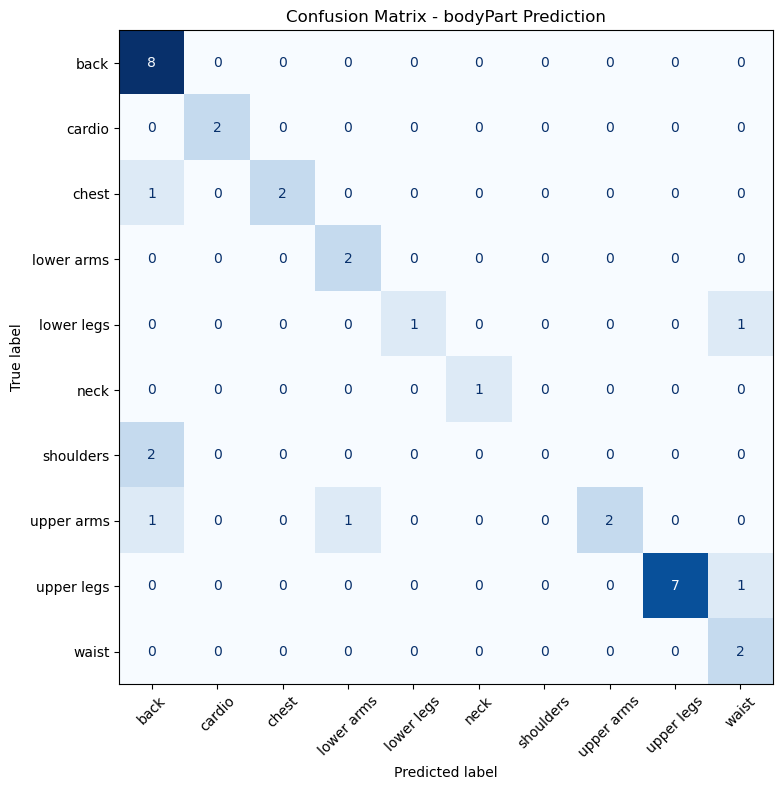


=== Sample Errors ===
                                exercise_name true_bodyPart pred_bodyPart
0                                kick out sit    upper legs         waist
1             barbell decline wide-grip press         chest          back
14  barbell seated behind head military press     shoulders          back
18                       barbell reverse curl    upper arms    lower arms
22                       circles knee stretch    lower legs         waist
24              barbell alternate biceps curl    upper arms          back
33                     barbell one arm snatch     shoulders          back

Saved:
- confusion_matrix.png
- errors.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 1) Load data
df = pd.read_csv(r"Desktop\exercise_dataset.csv")

# 2) Keep only needed columns
df = df[["name", "bodyPart"]].dropna()

X = df["name"].astype(str)
y = df["bodyPart"].astype(str)

print("Dataset size:", len(df))
print("\nClasses:")
print(y.value_counts())

# 3) Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4) Pipeline: TF-IDF + MLP
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1
    )),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    ))
])

# 5) Train
model.fit(X_train, y_train)

# 6) Predict
y_pred = model.predict(X_test)

# 7) Metrics
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("\n=== Results ===")
print(f"Accuracy     : {acc:.4f}")
print(f"Macro F1     : {macro_f1:.4f}")
print(f"Weighted F1  : {weighted_f1:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# 8) Confusion Matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - bodyPart Prediction")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()

# 9) Error analysis
errors = pd.DataFrame({
    "exercise_name": X_test.values,
    "true_bodyPart": y_test.values,
    "pred_bodyPart": y_pred
})

errors = errors[errors["true_bodyPart"] != errors["pred_bodyPart"]].copy()

print("\n=== Sample Errors ===")
print(errors.head(20))

errors.to_csv("errors.csv", index=False)
print("\nSaved:")
print("- confusion_matrix.png")
print("- errors.csv")

# Explaining:
The goal of this project was to predict the target body part (bodyPart) from the name of sport.
Since the input data is short text, the task was modeled as a text classification problem.

First, exercise names were converted into numerical features using TF-IDF Vectorization, which captures the importance of words in the dataset. Then, a Multi-Layer Perceptron (MLPClassifier) was used to perform the classification.

The final pipeline was:

Results

The model achieved the following performance on the test set:

Accuracy: 0.79

Macro F1 Score: 0.73

Weighted F1 Score: 0.77


# Error
The model performed well on classes with clear lexical cues such as upper legs, back, and cardio. However, it struggled with classes that share similar vocabulary, such as shoulders, upper arms, and lower arms. Words like press, curl, and barbell appear in exercises targeting multiple muscle groups, which can confuse the model.


# Conclusion

The TF-IDF + MLP pipeline provides a solid baseline for this task. However, performance is limited by the small dataset size, class imbalance, and overlapping exercise terminology. Future improvements could include testing other classifiers (e.g., Logistic Regression or SVM), using richer n-gram features, or expanding the dataset.